# Decision trees, random forests, & feature analysis

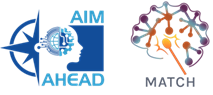

**Objectives:**


*   Visusalize decision trees
*   Observe the effect of boostraping on the robustness and accuracy of random forests (ensembles of decision trees) compared to single trees.
* Obtain Gini feature importances from a random forest classifier



**Acknowledgements** <br>
aiMATCH Hands-on Workshop Series: Predictive modeling using healthcare data. NIH AIM AHEAD DICB Program <br>
Principal Investigator: Amina Qutub, Ph.D., University of Texas at San Antonio<br>
Workshop Presenter and Code Author: Mignon Dumanjog, M.S., University of Texas at San Antonio<br>

# Import packages & data

In [ ]:
import numpy as np
import pandas as pd
import os

You can either load the data from Kaggle (through an API token which can be obtained from your Kaggle settings page), or from local files by uploading *train.csv*, *test.csv*, and *solution.csv* from the [aiMATCH GitHub page.](https://github.com/qutublab/aiMATCH/releases/tag/Predictive-modeling-workshop)<br>Run the cell corresponding to your chosen method.

*From Kaggle*

In [ ]:
# NEVER SHARE YOUR API TOKEN PUBLICLY.
# Tip: If using Google Colab, store your API token as a Secret.
# If running locally, do not commit your .env file or it will expose secrets
# that will allow others to control access to your various AI and authentication provider accounts.

import kagglehub
kagglehub.login()

aimatch_workshop_predicting_health_outcomes_path = kagglehub.competition_download('aimatch-workshop-predicting-health-outcomes')

print('Data source import complete.')

train_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Train.csv'))
test_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Test.csv'))
solution_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Solution.csv'))


Data source import complete.


*From files*

In [ ]:
train_df = pd.read_csv('/path/Train.csv') # change to actual path
test_df = pd.read_csv('/path/Test.csv') # change to actual path
solution_df = test_df = pd.read_csv('/path/Solution.csv') # change to actual path

# Set up training and test datasets + perform pre-processing

In [ ]:
X_train = train_df.iloc[:,1:-1]
y_train = train_df.iloc[:,-1]
y_train = y_train.replace({'CR/CRI': 1, 'NR': 0}).astype(int)
X_test = test_df.iloc[:,1:]

def id_column_type(df):
    numeric_columns = []
    text_columns = []
    for column_name in df.columns:

        if df[column_name].dtype in['int64','float64']:
            numeric_columns.append(df[column_name].name)
        else:
            text_columns.append(df[column_name].name)
    return numeric_columns, text_columns

numeric_features, categorical_features = id_column_type(X_train)

/tmp/ipykernel_50752/523191343.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({'CR/CRI': 1, 'NR': 0}).astype(int)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
numeric_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy = 'median')), # also try 'mean', 'most_frequent', etc.
        ("scaler", StandardScaler())
    ]
)

Xt_num = numeric_transformer.fit_transform(X_train[numeric_features])
Xt_num_df = pd.DataFrame(Xt_num, columns=numeric_features)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

Xt_cat = categorical_transformer.fit_transform(X_train[categorical_features])

ohe = categorical_transformer.named_steps["onehot"]

feature_names = ohe.get_feature_names_out(categorical_features)

Xt_cat_df = pd.DataFrame(
    Xt_cat.toarray(),
    columns=feature_names
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from graphviz import Source

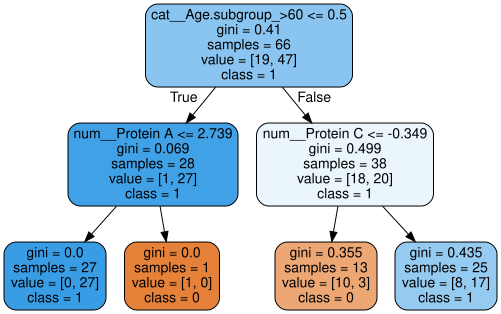

In [ ]:
dt = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", DecisionTreeClassifier(max_depth=2, random_state=42, criterion='gini')) # try max_depth=4 or removing the max_depth hyperparameter altogether
    ]
)

dt.fit(X_train, y_train)

feature_names = dt.named_steps["preprocess"].get_feature_names_out()
target_names = target_names = [str(x) for x in np.unique(y_train)]
# print(feature_names, target_names)

export_graphviz(
    dt.named_steps["classifier"],
    out_file="aml_tree.dot",
    feature_names=feature_names,
    class_names=target_names,
    rounded=True,
    filled=True
)

Source.from_file("aml_tree.dot")

In [ ]:
UPINs = test_df['UPIN']

y_dt_pred = dt.predict(X_test)
y_dt_proba = dt.predict_proba(X_test)[:, 1]
y_dt_pred_df = pd.DataFrame({'UPIN':UPINs, 'y_dt_pred':y_dt_pred, 'probability':y_dt_proba})

display(y_dt_pred_df)

## Uncomment & change file path to generate solution file if uploading to Kaggle
# submission = pd.DataFrame({'UPIN':UPINs, 'Response Simple':y_dt_pred})
# submission.to_csv('/path/submission.csv', index=False) # Save the DataFrame to a CSV file

,UPIN,y_dt_pred,probability
0,1000001,1,1.000000
1,1000002,1,1.000000
2,1000003,1,0.680000
3,1000004,0,0.000000
4,1000005,0,0.230769
5,1000006,0,0.230769
6,1000007,1,0.680000
7,1000008,1,0.680000
8,1000009,1,1.000000
9,1000010,1,1.000000


# Score decision tree model
Throughout our workshop, we will use the accuracy metric, given by the following equation, to evaluate the model. <br><br>
$ \text{accuracy} = \frac{\text{number of correctly predicted labels}}{\text{number of samples (in test set)}}$


In [ ]:
accuracy = (y_dt_pred == solution_df['Response Simple']).mean()
print(f"Accuracy: {accuracy}")

Accuracy: 0.6764705882352942


Try changing the max depth and resubmit. Did you notice any significant change in accuracy? Try removing the *random state* hyperparameter and re-running the model training block (starting with the definition of *dt* to accuracy calculation). Did your accuracy change over different runs? Variations can be expected.

---------------------------------

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=100, max_depth = 10, random_state=42)) # try max_depth=3, removing max_depth, n_estimators = 1000, etc.
    ]
)

rf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age.Dx', 'Weight.kg', 'BMI',
                                                   'HCT', 'Protein A',
                                                   'Protein B', 'Protein C']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['FAB.(Assigned)',
                                                   'Age.subgroup',
                                                   'Dysplasia'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=10, random_state=42))])

In [ ]:
y_rf_pred = rf.predict(X_test)
y_rf_proba = rf.predict_proba(X_test)[:, 1]
y_rf_pred_df = pd.DataFrame({'UPIN':UPINs, 'y_rf_pred':y_dt_pred, 'probability':y_rf_proba})
display(y_rf_pred_df)

## Uncomment & change file path to generate solution file if uploading to Kaggle
# submission = pd.DataFrame({'UPIN':UPINs, 'Response Simple':y_rf_pred})
# submission.to_csv('/path/submission.csv', index=False) # Save the DataFrame to a CSV file

,UPIN,y_rf_pred,probability
0,1000001,1,0.9200
1,1000002,1,0.9000
2,1000003,1,0.6600
3,1000004,0,0.6700
4,1000005,0,0.5300
5,1000006,0,0.2200
6,1000007,1,0.6000
7,1000008,1,0.6900
8,1000009,1,0.8500
9,1000010,1,0.9200


# Score random forest model


In [ ]:
accuracy = (y_rf_pred == solution_df['Response Simple']).mean()
print(f"Accuracy: {accuracy}")

Accuracy: 0.6764705882352942


Try changing the max depth and number of estimators. How did this affect the accuracy of the model? Try re-running the random forest pipeline (from definition of *rf* to accuracy), keeping the same hyperparameters but removing the *random_state*. As with decision trees, you can expect predictions to vary given the randomness involved in the model design.

# Gini feature importances

Gini importances indicate how much each feature contributes to making splits more pure in a decision tree. A limitation of this approach is that it reports higher importances for continuous features, so take this with a grain of salt. Also consider similar metrics such as *mean decrease accuracy* and *permutation importance*.

In [ ]:
rf_feature_importances = rf.named_steps["classifier"].feature_importances_
rf_feature_names = rf.named_steps["preprocess"].get_feature_names_out()

features_df = pd.DataFrame()
feature_dict = {'Name':[], 'Feature importance':[]}
for ft_im, name in zip(rf_feature_importances, rf_feature_names):
    feature_dict['Feature importance'].append(ft_im)
    feature_dict['Name'].append(name)
    # print(name, round(score,5))
features_df = pd.DataFrame(feature_dict)
features_df = features_df.sort_values(by='Feature importance', ascending=False)
display(features_df)

,Name,Feature importance
0,num__Age.Dx,0.177416
14,cat__Age.subgroup_>60,0.163004
5,num__Protein B,0.151891
1,num__Weight.kg,0.093562
6,num__Protein C,0.091313
2,num__BMI,0.085307
4,num__Protein A,0.059782
3,num__HCT,0.058072
13,cat__Age.subgroup_41-60,0.054079
8,cat__FAB.(Assigned)_M1,0.025677
